# Week 12 — Monday (Jun 22, Remote): FCN & U-Net

## Learning Objectives
- Understand the difference between classification, detection, and segmentation
- Implement a Fully Convolutional Network (FCN) with transposed convolution upsampling
- Build U-Net from scratch in PyTorch with symmetric skip connections
- Implement segmentation loss functions: pixel-wise CE, Dice, and combined
- Implement evaluation metrics: IoU, Dice coefficient, pixel accuracy
- Train and evaluate on a synthetic segmentation dataset

## Key Concepts
1. **Semantic segmentation** — assign a class label to every pixel
2. **FCN** — replace FC layers with 1×1 convolutions; upsample with transposed conv
3. **U-Net** — symmetric encoder-decoder with skip connections that preserve spatial detail
4. **Skip connections** — concatenate encoder features to decoder at matching resolution
5. **Dice loss** — `1 - (2|A∩B|) / (|A|+|B|)` — handles class imbalance better than CE
6. **IoU (Jaccard)** — `|A∩B| / |A∪B|` — standard segmentation evaluation metric

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Setup complete')

PyTorch 2.12.0+cpu | Device: cpu
Setup complete


## Section 1: Segmentation Task Overview

```
Classification :  one label  per IMAGE   →  "cat"
Detection      :  one label  per OBJECT  →  [(dog, bbox), (cat, bbox)]
Segmentation   :  one label  per PIXEL   →  dense mask of shape (H, W)
```

### Types of Segmentation

| Type | What it does | Distinguishes instances? |
|------|-------------|-------------------------|
| **Semantic** | Class per pixel (all dogs = same colour) | No |
| **Instance** | Separate mask per object | Yes |
| **Panoptic** | Semantic + Instance unified | Yes |

### Key Challenge: Spatial Resolution
Classification CNNs aggressively **downsample** (stride 32) — great for global features,
terrible for pixel-level prediction.
Segmentation networks must **recover spatial resolution** through upsampling.

### Upsampling Methods
| Method | How | Quality |
|--------|-----|--------|
| Nearest neighbour | Repeat pixels | Fast, blocky |
| Bilinear | Weighted interpolation | Smooth |
| Transposed conv | Learned upsampling | Best, learnable |

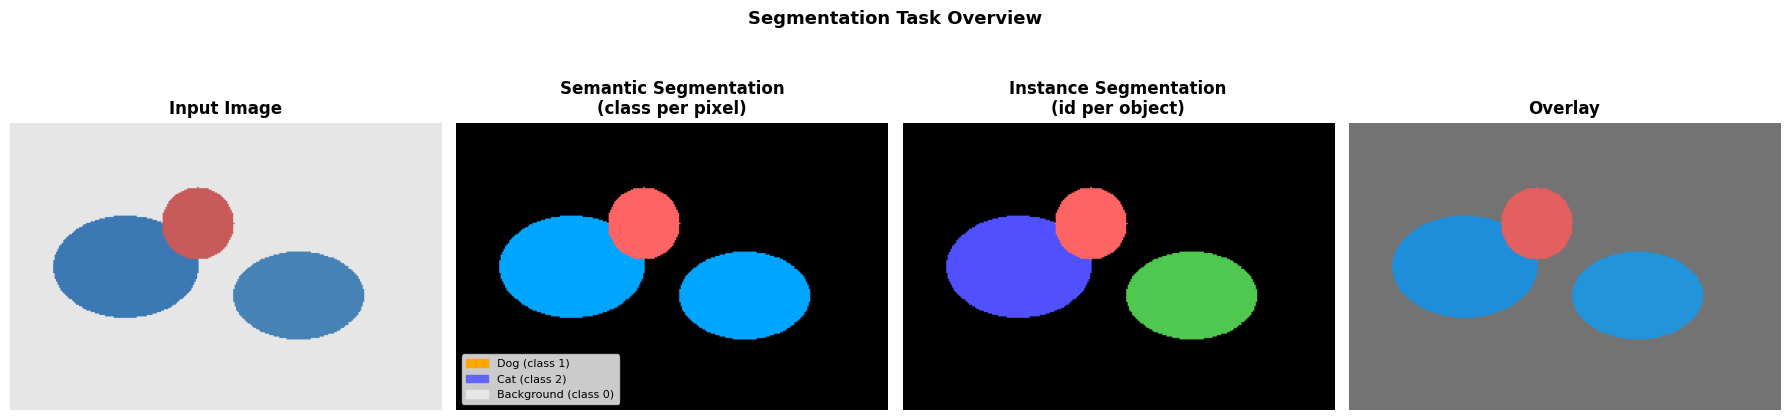

Saved segmentation_overview.png


In [2]:
# ── Visualise the three segmentation types ────────────────────────────────────
H, W = 200, 300
img = np.ones((H, W, 3), dtype=np.uint8) * 230

# Two dogs and one cat (synthetic coloured shapes)
cv2.ellipse(img, (80,  100), (50, 35), 0, 0, 360, (180, 120, 60), -1)  # dog 1
cv2.ellipse(img, (200, 120), (45, 30), 0, 0, 360, (180, 130, 70), -1)  # dog 2
cv2.circle(img,  (130, 70),  25, (90, 90, 200), -1)                    # cat

# Semantic mask (class colours)
sem = np.zeros((H, W, 3), dtype=np.uint8)
cv2.ellipse(sem, (80,  100), (50, 35), 0, 0, 360, (255, 165,  0), -1)  # dog = orange
cv2.ellipse(sem, (200, 120), (45, 30), 0, 0, 360, (255, 165,  0), -1)  # dog = orange
cv2.circle(sem,  (130, 70),  25, (100, 100, 255), -1)                   # cat = blue

# Instance mask (unique colour per object)
inst = np.zeros((H, W, 3), dtype=np.uint8)
cv2.ellipse(inst, (80,  100), (50, 35), 0, 0, 360, (255, 80,  80), -1)   # dog1 = red
cv2.ellipse(inst, (200, 120), (45, 30), 0, 0, 360, (80,  200, 80), -1)   # dog2 = green
cv2.circle(inst,  (130, 70),  25, (100, 100, 255), -1)                    # cat  = blue

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ['Input Image', 'Semantic Segmentation\n(class per pixel)',
          'Instance Segmentation\n(id per object)', 'Overlay']
imgs   = [img, sem, inst, cv2.addWeighted(img, 0.5, sem, 0.5, 0)]
for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontweight='bold'); ax.axis('off')

# Legend
patches = [mpatches.Patch(color='#FFA500', label='Dog (class 1)'),
           mpatches.Patch(color='#6464FF', label='Cat (class 2)'),
           mpatches.Patch(color='#E6E6E6', label='Background (class 0)')]
axes[1].legend(handles=patches, loc='lower left', fontsize=8)

plt.suptitle('Segmentation Task Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved segmentation_overview.png')

## Section 2: Fully Convolutional Network (FCN)

**Key idea (Long et al., 2015):** Replace the FC layers of a classification CNN with **1×1 convolutions**.
This makes the network accept any input size and produce a spatial output map.

### FCN Variants (skip connections)
```
VGG backbone
  └─ pool5  (stride 32)  ──────────────────────────────── upsample 32×  → FCN-32s
  └─ pool4  (stride 16)  ────────────── add ──────────── upsample 16×  → FCN-16s
  └─ pool3  (stride  8)  ── add ──────────────────────── upsample  8×  → FCN-8s
```
Each shallower skip connection adds **finer spatial detail** back to the prediction.

### Transposed Convolution (Deconv)
Inserts zeros between input values, then applies a learned filter — effectively a **learnable upsample**.
```
Input:  [a, b]  →  after insert:  [a, 0, b, 0]  →  conv with kernel  →  [c, d, e, f]
stride=2 transposed conv doubles spatial resolution
```

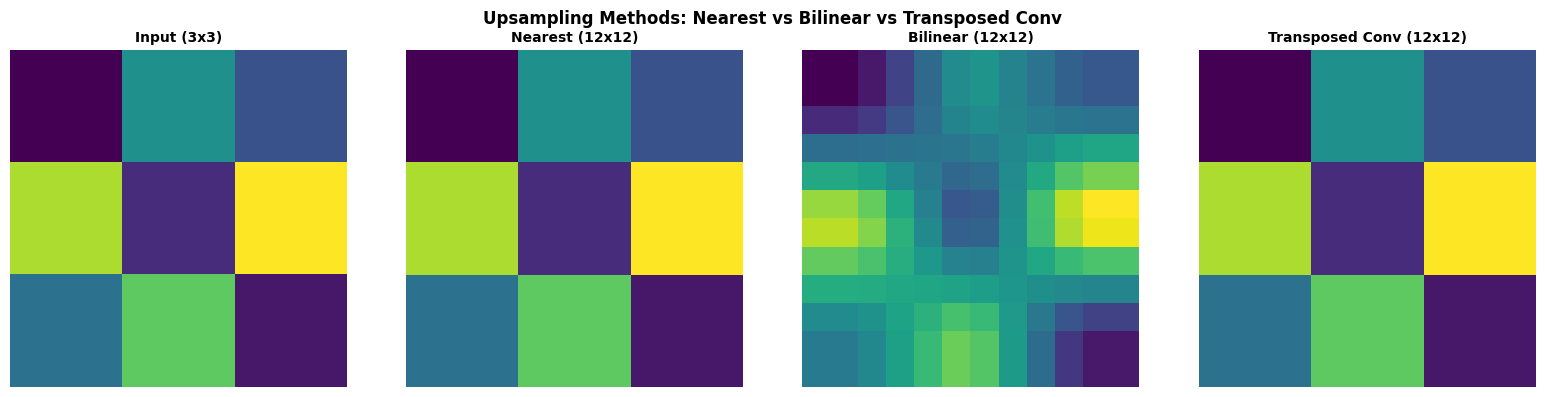

Minimal FCN — input: (1, 3, 256, 256)  output: (1, 3, 256, 256)
Parameters: 784,899
Saved upsampling_comparison.png


In [3]:
# ── Compare upsampling methods ────────────────────────────────────────────────
low_res = np.array([[10, 50, 30],
                    [80, 20, 90],
                    [40, 70, 15]], dtype=np.float32)

nearest  = cv2.resize(low_res, (12, 12), interpolation=cv2.INTER_NEAREST)
bilinear = cv2.resize(low_res, (12, 12), interpolation=cv2.INTER_LINEAR)

# Transposed conv (PyTorch)
t = torch.from_numpy(low_res).unsqueeze(0).unsqueeze(0)  # (1,1,3,3)
trans_conv = nn.ConvTranspose2d(1, 1, kernel_size=4, stride=4, padding=0, bias=False)
nn.init.ones_(trans_conv.weight)
with torch.no_grad():
    trans_out = trans_conv(t).squeeze().numpy()[:12, :12]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmaps = ['viridis'] * 4
for ax, title, im in zip(axes,
        ['Input (3x3)', 'Nearest (12x12)', 'Bilinear (12x12)', 'Transposed Conv (12x12)'],
        [low_res, nearest, bilinear, trans_out]):
    ax.imshow(im, cmap='viridis', interpolation='none')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Upsampling Methods: Nearest vs Bilinear vs Transposed Conv',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('upsampling_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Minimal FCN ───────────────────────────────────────────────────────────────
class MinimalFCN(nn.Module):
    """Demonstrates the FCN concept: conv encoder + transposed conv decoder."""
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder (stride 8 total)
        self.enc1 = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(),
                                   nn.MaxPool2d(2))   # /2
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
                                   nn.MaxPool2d(2))   # /4
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(),
                                   nn.MaxPool2d(2))   # /8
        # Bottleneck (1x1 conv — replaces FC)
        self.bottleneck = nn.Conv2d(128, 256, 1)
        # Decoder: transposed convolutions
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # x2
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # x4
            nn.ReLU(),
            nn.ConvTranspose2d(64, num_classes, 4, 2, 1),  # x8 → original size
        )

    def forward(self, x):
        x = self.enc3(self.enc2(self.enc1(x)))
        x = self.bottleneck(x)
        return self.dec(x)

fcn = MinimalFCN(num_classes=3)
dummy = torch.zeros(1, 3, 256, 256)
out   = fcn(dummy)
params = sum(p.numel() for p in fcn.parameters())
print(f'Minimal FCN — input: {tuple(dummy.shape)}  output: {tuple(out.shape)}')
print(f'Parameters: {params:,}')
print('Saved upsampling_comparison.png')

## Section 3: U-Net Architecture

Ronneberger et al. (2015) — originally for biomedical image segmentation.
U-Net's key innovation: **symmetric skip connections** concatenate encoder feature maps
to the decoder at each resolution level, restoring fine-grained spatial information.

```
Encoder (contracting)          Decoder (expansive)
─────────────────────          ──────────────────────
Input (3, 256, 256)
  │
 [DoubleConv → 64]  ───────────────────────────────> [UpConv → concat → DoubleConv]
  │ MaxPool /2                                                               │
 [DoubleConv → 128] ──────────────────────────> [UpConv → concat → DoubleConv]
  │ MaxPool /2                                                    │
 [DoubleConv → 256] ─────────────────────> [UpConv → concat → DoubleConv]
  │ MaxPool /2                                          │
 [DoubleConv → 512] ──────────────> [UpConv → concat → DoubleConv]
  │ MaxPool /2                                │
 [Bottleneck → 1024]  ──────────────────────┘
                                                        │
                                              Output Conv 1×1 → num_classes
```

**DoubleConv block:** Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU
**UpBlock:** Bilinear upsample × 2 → concat(skip) → DoubleConv

In [4]:
# ── U-Net from scratch ────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """Two consecutive Conv3x3 → BN → ReLU blocks."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    """MaxPool /2 → DoubleConv."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.pool   = nn.MaxPool2d(2)
        self.conv   = DoubleConv(in_c, out_c)
    def forward(self, x):
        return self.conv(self.pool(x))


class UpBlock(nn.Module):
    """Bilinear upsample × 2 → concat skip → DoubleConv."""
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.conv = DoubleConv(in_c + skip_c, out_c)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNet(nn.Module):
    """
    Standard U-Net.
    Input : (B, in_channels, H, W)  — H, W divisible by 16
    Output: (B, num_classes, H, W)
    """
    def __init__(self, in_channels=3, num_classes=2, features=(64, 128, 256, 512)):
        super().__init__()
        f = features
        # Encoder
        self.enc1   = DoubleConv(in_channels, f[0])
        self.enc2   = DownBlock(f[0], f[1])
        self.enc3   = DownBlock(f[1], f[2])
        self.enc4   = DownBlock(f[2], f[3])
        # Bottleneck
        self.bottle = DownBlock(f[3], f[3]*2)
        # Decoder
        self.dec4   = UpBlock(f[3]*2, f[3], f[3])
        self.dec3   = UpBlock(f[3],   f[2], f[2])
        self.dec2   = UpBlock(f[2],   f[1], f[1])
        self.dec1   = UpBlock(f[1],   f[0], f[0])
        # Output
        self.out    = nn.Conv2d(f[0], num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder — save for skip connections
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        # Bottleneck
        b  = self.bottle(s4)
        # Decoder
        d  = self.dec4(b,  s4)
        d  = self.dec3(d,  s3)
        d  = self.dec2(d,  s2)
        d  = self.dec1(d,  s1)
        return self.out(d)


# ── Inspect ───────────────────────────────────────────────────────────────────
NUM_CLASSES = 4   # background + 3 shape classes
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)

dummy = torch.zeros(1, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

total_params   = sum(p.numel() for p in model.parameters())
trainable_p    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('U-Net Architecture Summary')
print('=' * 45)
print(f'  Input  shape : {tuple(dummy.shape)}')
print(f'  Output shape : {tuple(out.shape)}')
print(f'  Total params : {total_params:,}  ({total_params/1e6:.2f}M)')
print(f'  Trainable    : {trainable_p:,}')
print(f'  Num classes  : {NUM_CLASSES}')

# Feature map sizes at each stage
print('\nFeature map sizes (256x256 input):')
stages = ['enc1 (64ch)', 'enc2 (128ch)', 'enc3 (256ch)', 'enc4 (512ch)',
          'bottle (1024ch)', 'dec4 (512ch)', 'dec3 (256ch)', 'dec2 (128ch)', 'dec1 (64ch)']
sizes  = [256, 128, 64, 32, 16, 32, 64, 128, 256]
for stage, sz in zip(stages, sizes):
    bar = '█' * (sz // 8)
    print(f'  {stage:20s}  {sz:3d}x{sz:<3d}  {bar}')

U-Net Architecture Summary
  Input  shape : (1, 3, 256, 256)
  Output shape : (1, 4, 256, 256)
  Total params : 31,385,028  (31.39M)
  Trainable    : 31,385,028
  Num classes  : 4

Feature map sizes (256x256 input):
  enc1 (64ch)           256x256  ████████████████████████████████
  enc2 (128ch)          128x128  ████████████████
  enc3 (256ch)           64x64   ████████
  enc4 (512ch)           32x32   ████
  bottle (1024ch)        16x16   ██
  dec4 (512ch)           32x32   ████
  dec3 (256ch)           64x64   ████████
  dec2 (128ch)          128x128  ████████████████
  dec1 (64ch)           256x256  ████████████████████████████████


## Section 4: Loss Functions for Segmentation

### Pixel-wise Cross-Entropy
$$\mathcal{L}_{CE} = -\frac{1}{H \times W} \sum_{h,w} \sum_c y_{h,w,c} \log \hat{p}_{h,w,c}$$

Problem: if 95% of pixels are background, CE is dominated by background — model learns to predict everything as background.

### Dice Loss
$$\mathcal{L}_{Dice} = 1 - \frac{2 \sum p \cdot y + \epsilon}{\sum p + \sum y + \epsilon}$$

- Directly optimises the Dice coefficient (= F1 score at pixel level)
- **Handles class imbalance** — cares equally about foreground and background
- `ε` (smooth=1.0) prevents division by zero

### Combined Loss (best in practice)
$$\mathcal{L} = \mathcal{L}_{CE} + \lambda \cdot \mathcal{L}_{Dice}$$
CE provides stable gradients; Dice handles imbalance. `λ = 1.0` is a common default.

Loss Comparison:
  Good prediction: CE=0.020  Dice=0.020  Combined=0.040
  Random / poor  : CE=1.388  Dice=0.749  Combined=2.138
  Always BG(biased): CE=3.784  Dice=0.891  Combined=4.675


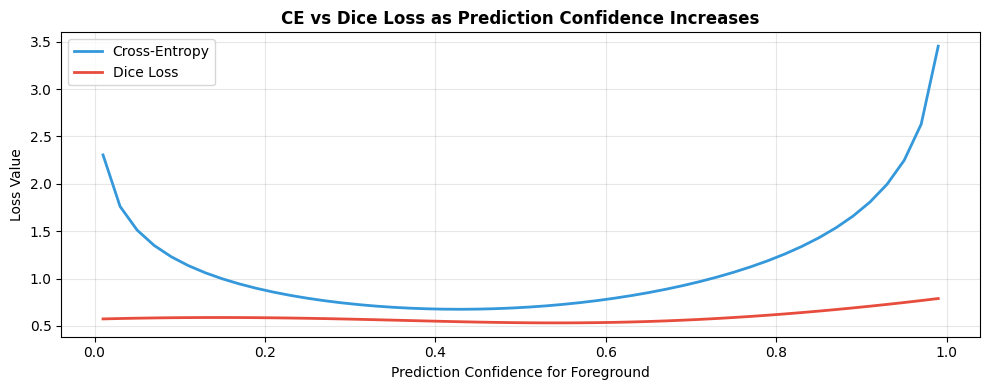

Saved loss_comparison.png


In [5]:
def dice_loss(pred_logits, targets, smooth=1.0):
    """
    Soft Dice loss for multi-class segmentation.
    pred_logits: (B, C, H, W) raw logits
    targets    : (B, H, W)    integer class labels
    """
    B, C, H, W = pred_logits.shape
    probs = F.softmax(pred_logits, dim=1)  # (B, C, H, W)

    # One-hot encode targets
    targets_oh = F.one_hot(targets.long(), C).permute(0, 3, 1, 2).float()  # (B,C,H,W)

    # Per-class Dice
    dice_per_class = []
    for c in range(C):
        p = probs[:, c]          # (B, H, W)
        t = targets_oh[:, c]     # (B, H, W)
        intersection = (p * t).sum()
        dice = (2 * intersection + smooth) / (p.sum() + t.sum() + smooth)
        dice_per_class.append(dice)

    mean_dice = torch.stack(dice_per_class).mean()
    return 1 - mean_dice


def combined_loss(pred_logits, targets, lam=1.0):
    """CE + lambda * Dice."""
    ce   = F.cross_entropy(pred_logits, targets.long())
    dice = dice_loss(pred_logits, targets)
    return ce + lam * dice, ce.item(), dice.item()


# ── Demo: compare losses on good vs bad predictions ──────────────────────────
B, C, H, W = 2, 4, 64, 64
targets = torch.randint(0, C, (B, H, W))

# Good prediction: logits that match targets
good_logits = torch.zeros(B, C, H, W)
for c in range(C):
    good_logits[:, c][targets == c] = 5.0  # high confidence where correct

# Poor prediction: uniform logits
poor_logits = torch.randn(B, C, H, W) * 0.1

# Background-dominated: always predict class 0
biased_logits = torch.zeros(B, C, H, W)
biased_logits[:, 0] = 5.0  # always background

print('Loss Comparison:')
print('=' * 55)
for name, logits in [('Good prediction', good_logits),
                      ('Random / poor  ', poor_logits),
                      ('Always BG(biased)', biased_logits)]:
    total, ce_val, dice_val = combined_loss(logits, targets)
    print(f'  {name}: CE={ce_val:.3f}  Dice={dice_val:.3f}  Combined={total:.3f}')

# ── Visualise Dice vs CE on a sweep ───────────────────────────────────────────
np.random.seed(0)
confidences = np.linspace(0.01, 0.99, 50)
ce_vals, dice_vals = [], []
for conf in confidences:
    tgt = torch.zeros(1, 64, 64, dtype=torch.long)
    tgt[0, 16:48, 16:48] = 1  # foreground square
    logit = torch.zeros(1, 2, 64, 64)
    logit[0, 1, 16:48, 16:48] = float(np.log(conf / (1 - conf + 1e-9)))
    logit[0, 0] = float(-np.log(conf / (1 - conf + 1e-9)))
    _, ce_v, d_v = combined_loss(logit, tgt)
    ce_vals.append(ce_v); dice_vals.append(d_v)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(confidences, ce_vals,   label='Cross-Entropy', color='#3498db', lw=2)
ax.plot(confidences, dice_vals, label='Dice Loss',     color='#e74c3c', lw=2)
ax.set_xlabel('Prediction Confidence for Foreground')
ax.set_ylabel('Loss Value')
ax.set_title('CE vs Dice Loss as Prediction Confidence Increases', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved loss_comparison.png')

## Section 5: Evaluation Metrics

### IoU (Intersection over Union / Jaccard Index)
$$\text{IoU}_c = \frac{|\text{pred}_c \cap \text{gt}_c|}{|\text{pred}_c \cup \text{gt}_c|}$$

**Mean IoU (mIoU)** — average IoU across all classes (standard benchmark metric).

### Dice Coefficient (F1 at pixel level)
$$\text{Dice}_c = \frac{2 |\text{pred}_c \cap \text{gt}_c|}{|\text{pred}_c| + |\text{gt}_c|}$$

Relationship: $\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}$

### Pixel Accuracy
$$\text{PA} = \frac{\text{correct pixels}}{\text{total pixels}}$$
Misleading when classes are imbalanced — use mIoU instead.

Segmentation Metrics:
  Background  : IoU=0.8968  Dice=0.9456
  Class 1     : IoU=0.6327  Dice=0.7751
  Class 2     : IoU=0.8223  Dice=0.9025
  Class 3     : IoU=0.8223  Dice=0.9025
  mIoU         : 0.7935
  mDice        : 0.8814
  Pixel Acc    : 0.9207


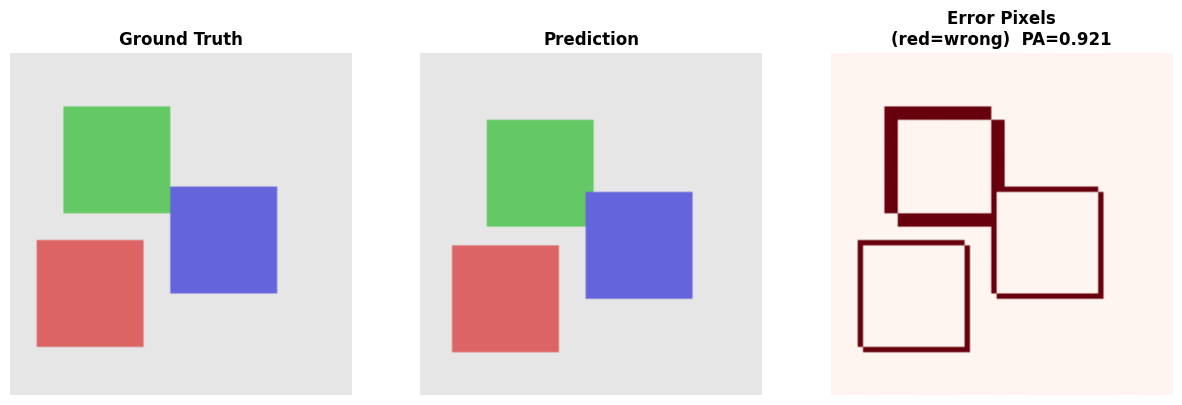

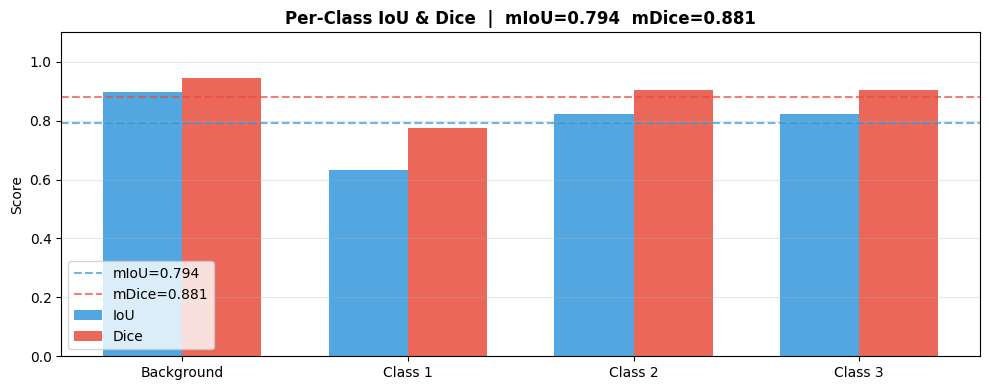

Saved metrics_demo.png


In [6]:
def compute_iou(pred_mask, gt_mask, num_classes):
    """Compute per-class IoU and mean IoU."""
    ious = []
    for c in range(num_classes):
        pred_c = (pred_mask == c)
        gt_c   = (gt_mask   == c)
        inter  = (pred_c & gt_c).sum().item()
        union  = (pred_c | gt_c).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(inter / union)
    valid = [v for v in ious if not np.isnan(v)]
    return ious, np.mean(valid)


def compute_dice(pred_mask, gt_mask, num_classes):
    """Compute per-class Dice coefficient."""
    dices = []
    for c in range(num_classes):
        pred_c = (pred_mask == c).float()
        gt_c   = (gt_mask   == c).float()
        inter  = (pred_c * gt_c).sum().item()
        denom  = pred_c.sum().item() + gt_c.sum().item()
        if denom == 0:
            dices.append(float('nan'))
        else:
            dices.append(2 * inter / denom)
    valid = [v for v in dices if not np.isnan(v)]
    return dices, np.mean(valid)


def pixel_accuracy(pred_mask, gt_mask):
    return (pred_mask == gt_mask).float().mean().item()


# ── Demo: evaluate a simulated prediction ─────────────────────────────────────
H, W = 128, 128
# Ground truth: 4-class mask
gt = torch.zeros(H, W, dtype=torch.long)
gt[20:60, 20:60] = 1   # class 1: square
gt[50:90, 60:100]= 2   # class 2: square
gt[70:110,10:50] = 3   # class 3: square

# Imperfect prediction (shifted slightly)
pred = torch.zeros(H, W, dtype=torch.long)
pred[25:65, 25:65] = 1
pred[52:92, 62:102]= 2
pred[72:112,12:52] = 3

ious, miou  = compute_iou(pred, gt, num_classes=4)
dices, mdice = compute_dice(pred, gt, num_classes=4)
pa = pixel_accuracy(pred, gt)

class_names = ['Background', 'Class 1', 'Class 2', 'Class 3']
print('Segmentation Metrics:')
print('=' * 50)
for name, iou, dice in zip(class_names, ious, dices):
    iou_s  = f'{iou:.4f}'  if not np.isnan(iou)  else 'N/A'
    dice_s = f'{dice:.4f}' if not np.isnan(dice) else 'N/A'
    print(f'  {name:12s}: IoU={iou_s}  Dice={dice_s}')
print(f'  mIoU         : {miou:.4f}')
print(f'  mDice        : {mdice:.4f}')
print(f'  Pixel Acc    : {pa:.4f}')

# ── Visualise ─────────────────────────────────────────────────────────────────
cmap_colors = np.array([[230,230,230],[100,200,100],[100,100,220],[220,100,100]], dtype=np.uint8)
gt_rgb   = cmap_colors[gt.numpy()]
pred_rgb = cmap_colors[pred.numpy()]
diff     = (gt != pred).numpy().astype(np.uint8) * 255

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_rgb);   axes[0].set_title('Ground Truth', fontweight='bold')
axes[1].imshow(pred_rgb); axes[1].set_title('Prediction', fontweight='bold')
axes[2].imshow(diff, cmap='Reds'); axes[2].set_title(f'Error Pixels\n(red=wrong)  PA={pa:.3f}', fontweight='bold')
for ax in axes: ax.axis('off')

# Metrics bar chart
fig2, ax2 = plt.subplots(figsize=(10, 4))
x = np.arange(4)
w = 0.35
valid_ious  = [v if not np.isnan(v) else 0 for v in ious]
valid_dices = [v if not np.isnan(v) else 0 for v in dices]
ax2.bar(x - w/2, valid_ious,  w, label='IoU',  color='#3498db', alpha=0.85)
ax2.bar(x + w/2, valid_dices, w, label='Dice', color='#e74c3c', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(class_names)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Score')
ax2.set_title(f'Per-Class IoU & Dice  |  mIoU={miou:.3f}  mDice={mdice:.3f}', fontweight='bold')
ax2.axhline(miou,  color='#3498db', ls='--', alpha=0.7, label=f'mIoU={miou:.3f}')
ax2.axhline(mdice, color='#e74c3c', ls='--', alpha=0.7, label=f'mDice={mdice:.3f}')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved metrics_demo.png')

## Section 6: Synthetic Dataset & Training Loop

We build a toy segmentation dataset with 3 foreground classes (circle, rectangle, triangle)
and train the U-Net for a few epochs to verify the pipeline is end-to-end correct.

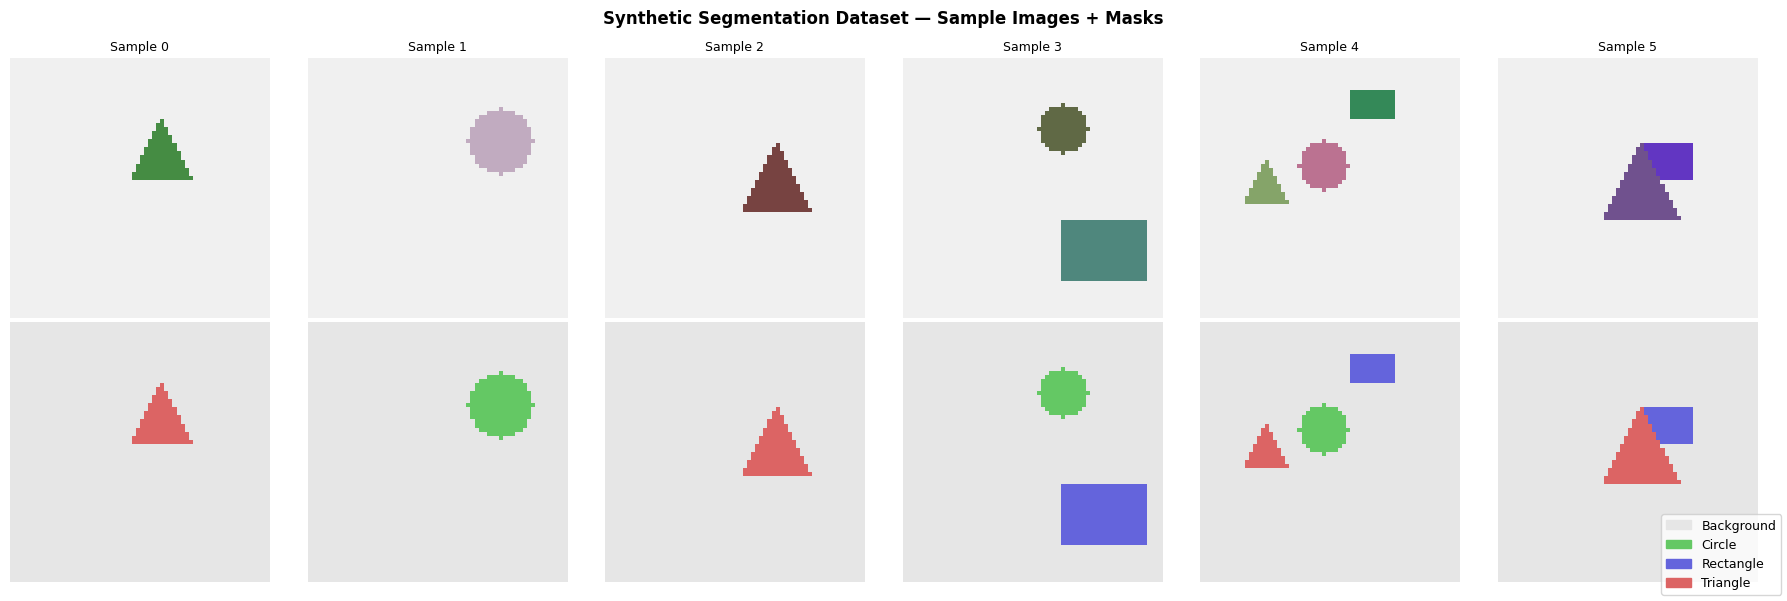

Train: 120 samples | Val: 30 samples
Batch shape: images=(8, 3, 64, 64)  masks=(8, 64, 64)


In [7]:
class SynthSegDataset(Dataset):
    """
    Synthetic segmentation dataset.
    Returns (image, mask) where mask has classes 0=bg, 1=circle, 2=rect, 3=triangle.
    """
    def __init__(self, n_samples=200, img_size=64):
        self.n   = n_samples
        self.sz  = img_size

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(idx)
        sz  = self.sz
        img  = np.full((sz, sz, 3), 240, dtype=np.uint8)
        mask = np.zeros((sz, sz),   dtype=np.uint8)   # uint8 for OpenCV drawing

        n_shapes = rng.integers(1, 4)
        for _ in range(n_shapes):
            cls    = int(rng.integers(1, 4))
            size   = int(rng.integers(10, 22))
            margin = size // 2 + 4
            cx     = int(rng.integers(margin, sz - margin))
            cy     = int(rng.integers(margin, sz - margin))
            col    = tuple(int(v) for v in rng.integers(50, 200, 3))

            if cls == 1:   # circle
                cv2.circle(img,  (cx, cy), size//2, col, -1)
                cv2.circle(mask, (cx, cy), size//2, 1,   -1)
            elif cls == 2: # rectangle
                x1, y1 = cx - size//2, cy - size//3
                x2, y2 = cx + size//2, cy + size//3
                cv2.rectangle(img,  (x1, y1), (x2, y2), col, -1)
                cv2.rectangle(mask, (x1, y1), (x2, y2), 2,   -1)
            else:          # triangle
                pts = np.array([[cx, cy-size//2],
                                [cx-size//2, cy+size//2],
                                [cx+size//2, cy+size//2]], dtype=np.int32)
                cv2.fillPoly(img,  [pts], col)
                cv2.fillPoly(mask, [pts], (3,))

        img_t  = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask_t = torch.from_numpy(mask.astype(np.int64))  # long for cross-entropy
        return img_t, mask_t


# ── Build DataLoaders ─────────────────────────────────────────────────────────
train_ds = SynthSegDataset(n_samples=120, img_size=64)
val_ds   = SynthSegDataset(n_samples=30,  img_size=64)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False)

# Preview samples
imgs_s, masks_s = next(iter(train_dl))
cmap_rgb = np.array([[230,230,230],[100,200,100],[100,100,220],[220,100,100]], dtype=np.uint8)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    img_np  = imgs_s[i].permute(1,2,0).numpy()
    mask_np = masks_s[i].numpy().astype(np.int64)
    axes[0,i].imshow(img_np); axes[0,i].axis('off')
    axes[1,i].imshow(cmap_rgb[mask_np]); axes[1,i].axis('off')
    axes[0,i].set_title(f'Sample {i}', fontsize=9)
axes[0,0].set_ylabel('Image', fontsize=10, fontweight='bold')
axes[1,0].set_ylabel('Mask', fontsize=10, fontweight='bold')

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for c,n in zip(cmap_rgb, ['Background','Circle','Rectangle','Triangle'])]
fig.legend(handles=patches, loc='lower right', fontsize=9)
plt.suptitle('Synthetic Segmentation Dataset — Sample Images + Masks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_preview.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
print(f'Batch shape: images={tuple(imgs_s.shape)}  masks={tuple(masks_s.shape)}')

In [8]:
# ── Training loop ─────────────────────────────────────────────────────────────
model     = UNet(in_channels=3, num_classes=4, features=(16, 32, 64, 128)).to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=10, eta_min=1e-5)
N_EPOCHS  = 10

history = {'train_loss': [], 'val_loss': [], 'val_miou': [], 'val_dice': []}

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    t_loss = 0.0
    for imgs, masks in train_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimiser.zero_grad()
        logits = model(imgs)
        loss, _, _ = combined_loss(logits, masks)
        loss.backward()
        optimiser.step()
        t_loss += loss.item()
    scheduler.step()

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    v_loss, all_miou, all_dice = 0.0, [], []
    with torch.no_grad():
        for imgs, masks in val_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            loss, _, _ = combined_loss(logits, masks)
            v_loss += loss.item()
            preds = logits.argmax(dim=1)
            for pred, gt in zip(preds, masks):
                _, miou_v  = compute_iou(pred.cpu(),  gt.cpu(),  num_classes=4)
                _, dice_v  = compute_dice(pred.cpu(), gt.cpu(), num_classes=4)
                all_miou.append(miou_v); all_dice.append(dice_v)

    tl = t_loss / len(train_dl)
    vl = v_loss / len(val_dl)
    mi = np.nanmean(all_miou)
    di = np.nanmean(all_dice)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_miou'].append(mi)
    history['val_dice'].append(di)

    print(f'Epoch {epoch:2d}/{N_EPOCHS} | '
          f'Train: {tl:.4f} | Val: {vl:.4f} | '
          f'mIoU: {mi:.4f} | mDice: {di:.4f}')

print(f'\nFinal mIoU : {history["val_miou"][-1]:.4f}')
print(f'Final mDice: {history["val_dice"][-1]:.4f}')

Epoch  1/10 | Train: 2.3266 | Val: 2.3146 | mIoU: 0.0127 | mDice: 0.0237


Epoch  2/10 | Train: 2.1008 | Val: 2.1475 | mIoU: 0.0139 | mDice: 0.0261


Epoch  3/10 | Train: 1.9744 | Val: 2.0099 | mIoU: 0.1304 | mDice: 0.1741


Epoch  4/10 | Train: 1.8893 | Val: 1.8296 | mIoU: 0.3014 | mDice: 0.3819


Epoch  5/10 | Train: 1.8239 | Val: 1.7893 | mIoU: 0.4709 | mDice: 0.5497


Epoch  6/10 | Train: 1.7908 | Val: 1.7679 | mIoU: 0.5177 | mDice: 0.5946


Epoch  7/10 | Train: 1.7606 | Val: 1.7383 | mIoU: 0.5294 | mDice: 0.5991


Epoch  8/10 | Train: 1.7472 | Val: 1.7208 | mIoU: 0.5585 | mDice: 0.6272


Epoch  9/10 | Train: 1.7314 | Val: 1.7128 | mIoU: 0.5725 | mDice: 0.6421


Epoch 10/10 | Train: 1.7314 | Val: 1.7084 | mIoU: 0.5720 | mDice: 0.6420

Final mIoU : 0.5720
Final mDice: 0.6420


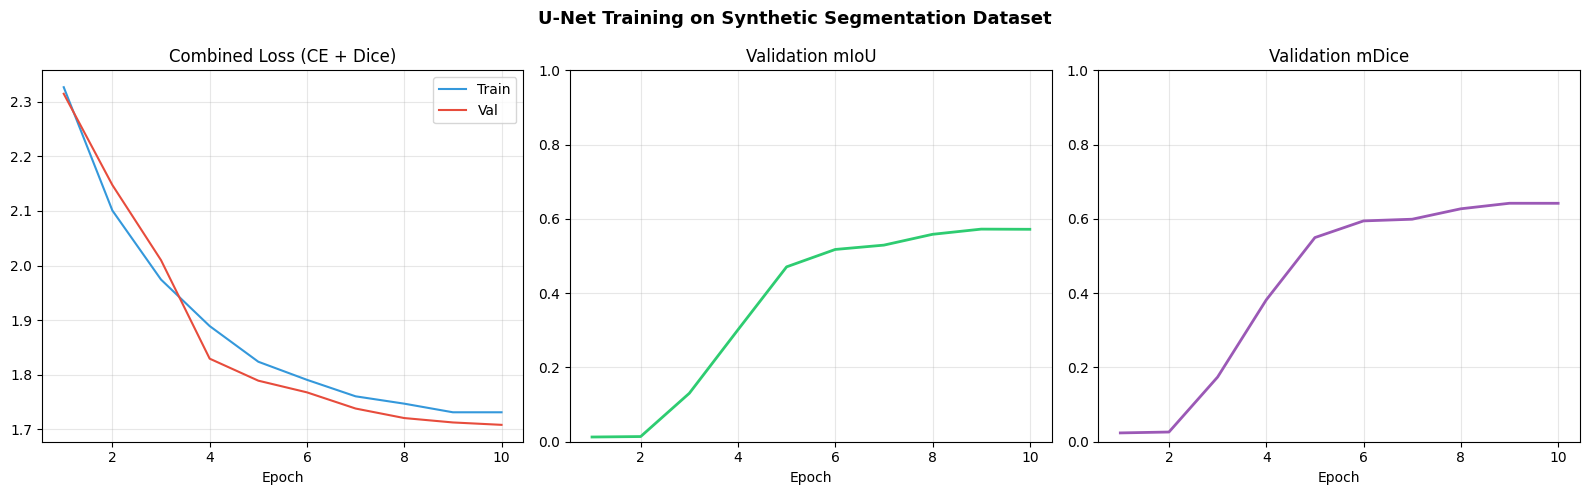

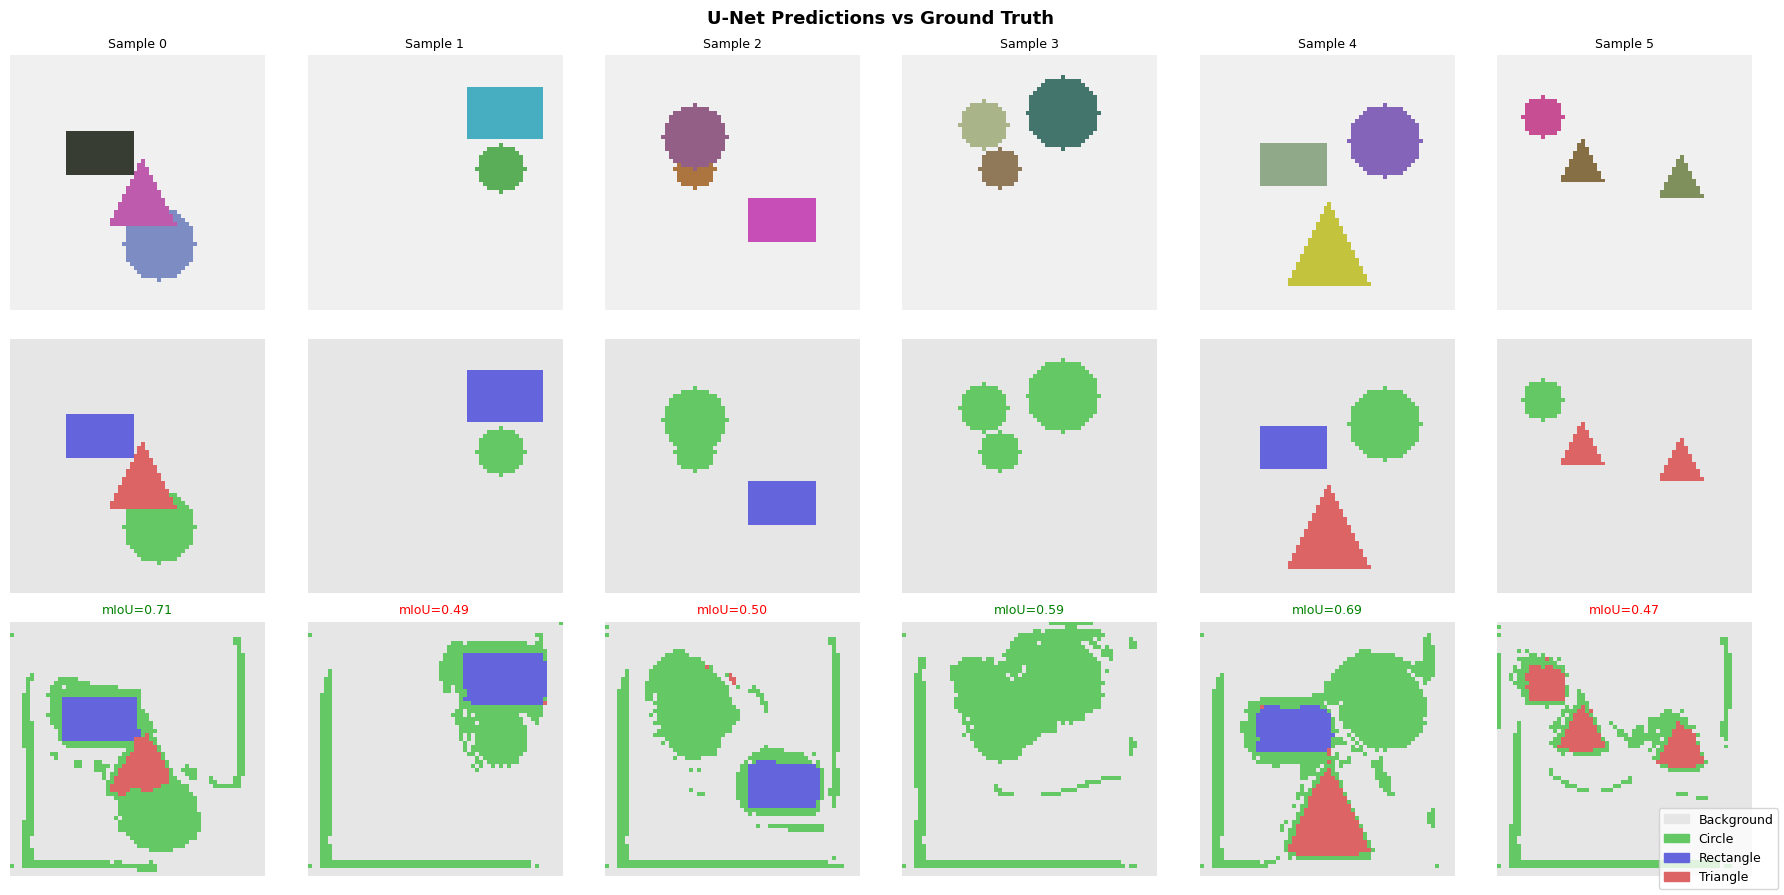

Saved training_history.png  unet_predictions.png


In [9]:
# ── Plot training history ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ep = range(1, N_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='#3498db')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Combined Loss (CE + Dice)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['val_miou'], color='#2ecc71', lw=2)
axes[1].set_title('Validation mIoU'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, history['val_dice'], color='#9b59b6', lw=2)
axes[2].set_title('Validation mDice'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1); axes[2].grid(True, alpha=0.3)

plt.suptitle('U-Net Training on Synthetic Segmentation Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Visualise predictions vs ground truth ─────────────────────────────────────
model.eval()
imgs_v, masks_v = next(iter(val_dl))
with torch.no_grad():
    preds_v = model(imgs_v.to(DEVICE)).argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i in range(6):
    axes[0,i].imshow(imgs_v[i].permute(1,2,0).numpy())
    axes[1,i].imshow(cmap_rgb[masks_v[i].numpy()])
    axes[2,i].imshow(cmap_rgb[preds_v[i].numpy()])
    _, mi = compute_iou(preds_v[i], masks_v[i], 4)
    axes[0,i].set_title(f'Sample {i}', fontsize=9)
    axes[2,i].set_title(f'mIoU={mi:.2f}', fontsize=9, color='green' if mi > 0.5 else 'red')
    for r in range(3): axes[r,i].axis('off')

axes[0,0].set_ylabel('Input', fontsize=10, fontweight='bold')
axes[1,0].set_ylabel('Ground Truth', fontsize=10, fontweight='bold')
axes[2,0].set_ylabel('Prediction', fontsize=10, fontweight='bold')
fig.legend(handles=patches, loc='lower right', fontsize=9)
plt.suptitle('U-Net Predictions vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('unet_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved training_history.png  unet_predictions.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Semantic seg** | One class label per pixel; output shape matches input shape |
| **FCN** | Replace FC with 1×1 conv; upsample with transposed conv (learned) |
| **U-Net** | Symmetric encoder-decoder; skip connections concatenate encoder to decoder |
| **DoubleConv** | Two 3×3 convs + BN + ReLU per block — standard U-Net building block |
| **Skip connections** | Preserve spatial detail lost during downsampling |
| **Dice loss** | `1 - 2|p∩t|/(|p|+|t|)` — handles class imbalance, directly optimises F1 |
| **CE + Dice** | Combined loss: stable CE gradients + imbalance-aware Dice |
| **mIoU** | Mean IoU across classes — primary segmentation benchmark metric |

### Architecture Comparison: FCN vs U-Net
| Property | FCN | U-Net |
|----------|-----|-------|
| Skip connections | Additive (FCN-8s) | Concatenation |
| Decoder depth | Single transposed conv | Full symmetric decoder |
| Best for | Large datasets, natural images | Small datasets, medical imaging |
| Original use | Pascal VOC | Biomedical cell segmentation |

### Exercises
1. Replace bilinear upsampling in `UpBlock` with a `ConvTranspose2d` — does performance change?
2. Add dropout (p=0.5) to the bottleneck — measure effect on overfitting.
3. Implement **Focal loss** for segmentation: `FL = -α(1-p)^γ log(p)` with γ=2.
4. Increase U-Net depth to 5 levels — what happens to memory and performance?
5. Train on a real dataset: Oxford-IIIT Pets (torchvision has it built-in).